# Chapter 14 Bayesian Experimentation for A/B Testing: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-14-bayesian-ab-testing-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

At 1,000 visitors per variant, a two-proportion z-test on a checkout-button redesign returns a
p-value of 0.126. That test asks a narrow question: whether two observed conversion rates
differ by more than chance alone would plausibly explain.

Under the conventional 0.05 threshold, the 0.126 result is not significant: the frequentist
framework says stop, you cannot reject the null.

A Bayesian model fit to the same 2,000 visitors says the redesign has a 93.7% chance of beating
the original. If that 93.7% turns out to be wrong, shipping it now carries an average cost of
0.038 percentage points of conversion.

Both statements are correct. They are answers to different questions, and knowing which
question you are asking is most of what this part of the book is about.

Part 1 introduced Bayes' theorem and frequentist hypothesis testing as two separate tools. This
part treats Bayesian inference as a full alternative to the hypothesis-testing machinery from
Chapter 2.

It gives a way to run an experiment, watch it while it runs, and make a shipping decision
without waiting for a p-value to cross a line someone picked in advance.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(101)

## Priors: how much to assume before the data arrives

Each curve puts the same 10% central belief on the x-axis (conversion rate, 0% to 40%) but spreads that belief differently: the uninformative prior spans almost the full range, while the highly informative prior shown here, built from about 10,000 pseudo-observations, concentrates nearly all its density within a percentage point of 10%. The stronger the prior, the more data it takes to move it.

In [4]:
def fig_prior_shapes() -> go.Figure:
    priors = [(1, 1), (11, 91), (50, 450), (200, 1800), (1000, 9000)]
    labels = ["Beta(1,1) uninformative", "Beta(11,91) weakly informative (~100 obs.)",
              "Beta(50,450) more confident (~500 obs.)",
              "Beta(200,1800) strongly informative (~2,000 obs.)",
              "Beta(1000,9000) highly informative (~10,000 obs.)"]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for (a, b), label in zip(priors, labels):
        pdf = stats.beta.pdf(x, a, b)
        frames.append(
            go.Frame(
                name=label,
                data=[go.Scatter(x=x_list, y=pdf.tolist(), mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8", width=2.5))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"mean = {a / (a + b):.1%}, pseudo-observations = {a + b - 2:.0f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A prior expresses the same 10% central belief at five different strengths",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior: "},
            "steps": [
                # Short display labels on purpose: the full frame names (e.g.
                # "Beta(1000,9000) highly informative (~10,000 obs.)") overhang past
                # the plot's right margin at the slider's end positions and get
                # clipped by the plot boundary. Even the shortened "Beta(1000,9000)"
                # form still clipped by a couple of characters at the rightmost step,
                # so the label drops the "Beta" prefix too and the right margin grows
                # to give the last tick's centered text room to breathe. Frame names
                # stay unchanged below since the animate() call targets them by name.
                {"label": short, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f, short in zip(frames, ["(1,1)", "(11,91)", "(50,450)",
                                              "(200,1800)", "(1000,9000)"])
            ],
        }],
        margin=dict(t=60, l=60, r=60, b=50),
    )
    return fig

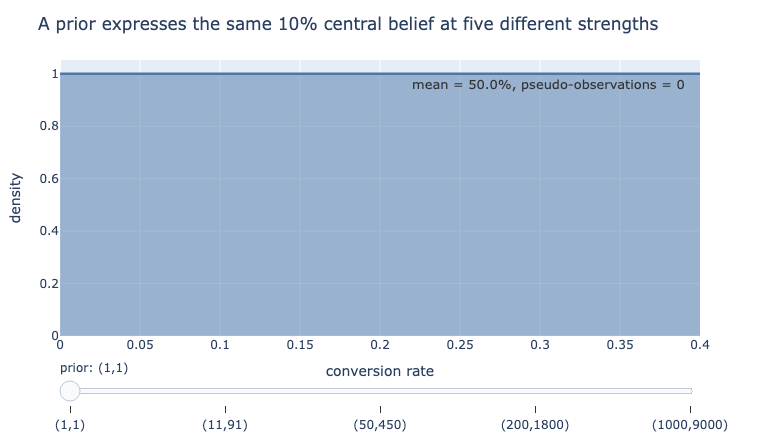

In [5]:
show(fig_prior_shapes())

## Beta-Binomial conjugacy

A single variant's posterior narrows and settles as observed visitors accumulate. Early swings are large; by a few thousand visitors, new data barely moves it.

In [6]:
def fig_posterior_update() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_rate = 0.10
    sample_sizes = [0, 25, 100, 500, 2000, 8000]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        conv = RNG.binomial(n, true_rate) if n else 0
        a, b = prior_a + conv, prior_b + (n - conv)
        mean = a / (a + b)
        frames.append(
            go.Frame(
                name=str(n),
                data=[go.Scatter(x=x_list, y=stats.beta.pdf(x, a, b).tolist(), mode="lines",
                                  fill="tozeroy", line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"n = {n}, conversions = {conv}<br>"
                          f"posterior mean = {mean:.1%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A single variant's Beta(1,1) posterior narrows and settles as visitors accumulate",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors observed: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

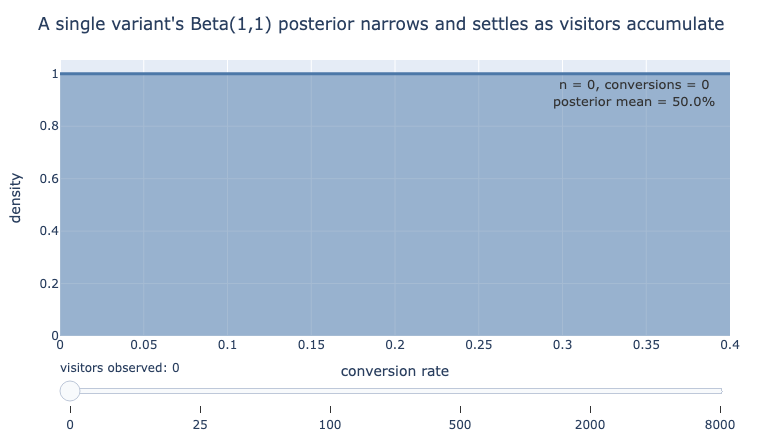

In [7]:
show(fig_posterior_update())

## Two variants, one decision

Variant A and Variant B posteriors separate as each group collects data. By a few thousand visitors per variant, the two curves barely overlap.

In [8]:
def fig_ab_overlay() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 1000, 5000]
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=3)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"A: {a_conv}/{n} conversions, B: {b_conv}/{n} conversions",
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Variant A and Variant B posteriors separate as each group collects data",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

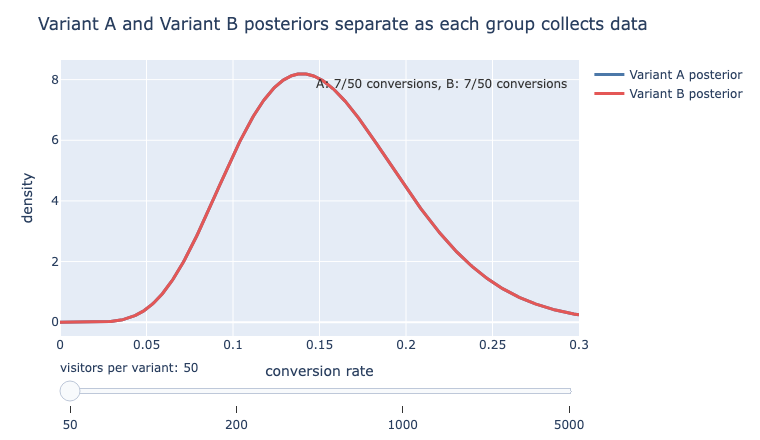

In [9]:
show(fig_ab_overlay())

## Expected loss as a stopping rule

Win probability and expected loss from choosing B, as the sample size grows. Expected loss stays a steadier guide than win probability when the sample is still small.

In [10]:
def fig_decision_metrics() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 500, 1000, 2000, 5000]
    n_samples = 200_000
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)

        a_draws = RNG.beta(aa, ab, size=n_samples)
        b_draws = RNG.beta(ba, bb, size=n_samples)
        p_b_best = float(np.mean(b_draws > a_draws))
        expected_loss_b = float(np.mean(np.maximum(a_draws - b_draws, 0)))

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=2)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"A: {a_conv}/{n}, B: {b_conv}/{n}<br>"
                          f"P(B beats A) = {p_b_best:.1%}<br>"
                          f"expected loss choosing B = {expected_loss_b:.4f}"),
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Win probability and expected loss, computed from the same posteriors, as n grows",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

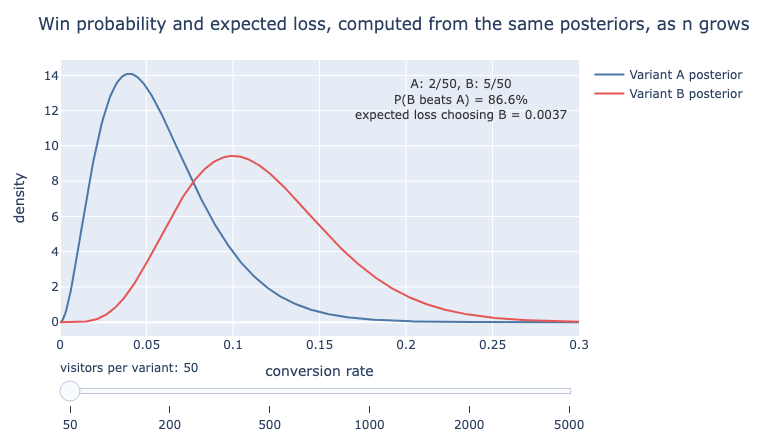

In [11]:
show(fig_decision_metrics())

## Continuous monitoring and the peeking problem

False-positive rate under a true null, as the number of times the test is checked grows. A single fixed-horizon check holds the nominal 5%; five checks push it past 14%.

In [12]:
def fig_peeking_problem() -> go.Figure:
    n_simulations = 3000
    max_n = 6000
    look_counts = [1, 2, 5, 10, 20, 40]
    rate = 0.10

    control = RNG.binomial(1, rate, size=(n_simulations, max_n))
    treatment = RNG.binomial(1, rate, size=(n_simulations, max_n))  # same rate: null is true
    control_cum = np.cumsum(control, axis=1)
    treatment_cum = np.cumsum(treatment, axis=1)

    frames = []
    for looks in look_counts:
        check_points = np.linspace(max_n // looks, max_n, looks).astype(int) - 1
        rejected = np.zeros(n_simulations, dtype=bool)
        for idx in check_points:
            n = idx + 1
            p1 = control_cum[:, idx] / n
            p2 = treatment_cum[:, idx] / n
            pooled = (control_cum[:, idx] + treatment_cum[:, idx]) / (2 * n)
            se = np.sqrt(pooled * (1 - pooled) * (2 / n)) + 1e-12
            z = (p2 - p1) / se
            rejected |= np.abs(z) > 1.96
        false_positive_rate = float(np.mean(rejected))
        frames.append(
            go.Frame(
                name=str(looks),
                data=[go.Bar(x=["False-positive rate"], y=[false_positive_rate],
                              marker_color="#E45756", width=[0.5],
                              text=[f"{false_positive_rate:.1%}"], textposition="outside")],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=-0.5, x1=0.5, y0=0.05, y1=0.05,
                    line=dict(color="#333", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Checking a fixed-horizon significance test repeatedly inflates the "
              "false-positive rate above the nominal 5%",
        yaxis_title="false-positive rate under a true null",
        yaxis_range=[0, 0.5],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "number of times the test is checked: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=80, l=60, r=30, b=50),
    )
    return fig

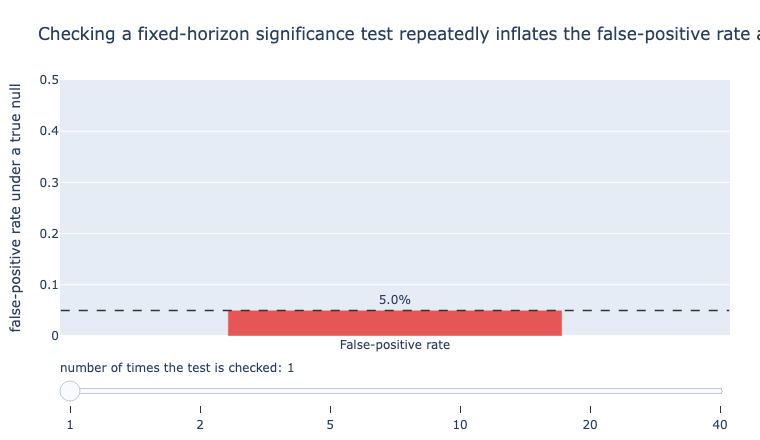

In [13]:
show(fig_peeking_problem())

## Beyond conversion rates

The average-order-value posterior narrows and slides from the \$42 prior toward the observed \$44.10 sample mean as converting visitors accumulate. Move the slider.

In [14]:
def fig_normal_normal_update() -> go.Figure:
    prior_mean, prior_sd = 42.0, 5.0
    prior_var = prior_sd**2
    sample_mean, sample_sd = 44.10, 18.0
    data_var = sample_sd**2

    sample_sizes = [0, 10, 50, 150, 500]
    x_grid = np.linspace(20, 60, 400)
    x_list = x_grid.tolist()

    prior_density = stats.norm.pdf(x_grid, loc=prior_mean, scale=prior_sd).tolist()

    frames = []
    for n in sample_sizes:
        tau_prior = 1.0 / prior_var
        tau_data = n / data_var
        tau_post = tau_prior + tau_data
        post_mean = (tau_prior * prior_mean + tau_data * sample_mean) / tau_post
        post_sd = np.sqrt(1.0 / tau_post)
        posterior_density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=prior_density, mode="lines",
                               line=dict(color="#B7C7DB", width=2, dash="dot"),
                               name="prior: N(42, 5²)"),
                    go.Scatter(x=x_list, y=posterior_density.tolist(), mode="lines",
                               fill="tozeroy", line=dict(color="#4C78A8", width=2.5),
                               name="posterior"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"n = {n} converting visitors<br>"
                          f"posterior mean = ${post_mean:.2f}, posterior sd = ${post_sd:.2f}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A Normal prior on average order value narrows toward the observed "
              "$44.10 sample mean as n grows",
        xaxis_title="average order value ($)",
        yaxis_title="density",
        xaxis_range=[20, 60],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "converting visitors observed: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

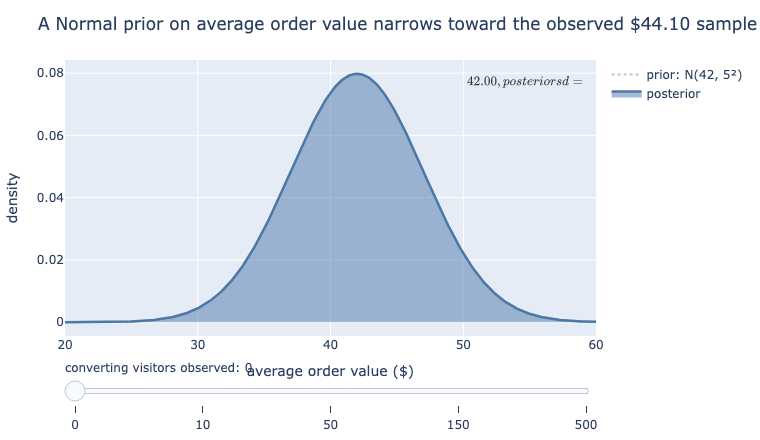

In [15]:
show(fig_normal_normal_update())

## Sample ratio mismatch: checking the split before trusting the comparison

Cumulative logged traffic by variant, week over week. Weeks 1 and 2 sit close to the dashed 50% line; a redirect-timeout bug shipped after Week 2 pulls Variant B's share down every week after, crossing the flag threshold by Week 5.

In [16]:
def fig_srm_check() -> go.Figure:
    rng = np.random.default_rng(303)
    weekly_n = [15000, 15000, 15000, 15000, 15000]
    week_labels = ["Week 1", "Week 2", "Week 3", "Week 4", "Week 5"]
    # Weeks 1-2: healthy 50/50 randomization, everything assigned gets logged. After Week 2 a
    # redirect-timeout bug ships on Variant B's path and starts dropping about 6% of assigned-B
    # visitors from the logging pipeline before a conversion is ever recorded for them; Variant
    # A's path is untouched, so its logged count always matches its assigned count.
    drop_rate_b = [0.0, 0.0, 0.06, 0.06, 0.06]

    cum_a, cum_b = 0, 0
    frames = []
    for label, n, drop in zip(week_labels, weekly_n, drop_rate_b):
        assigned_a = rng.binomial(n, 0.5)
        assigned_b = n - assigned_a
        logged_a = assigned_a
        logged_b = rng.binomial(assigned_b, 1 - drop)
        cum_a += logged_a
        cum_b += logged_b
        total = cum_a + cum_b
        expected = total / 2
        chi2 = ((cum_a - expected) ** 2) / expected + ((cum_b - expected) ** 2) / expected
        p_value = float(stats.chi2.sf(chi2, df=1))
        flagged = p_value < 0.001
        pct_a, pct_b = cum_a / total * 100, cum_b / total * 100
        frames.append(
            go.Frame(
                name=label,
                data=[go.Bar(x=["Variant A", "Variant B"], y=[pct_a, pct_b],
                              marker_color=["#4C78A8", "#E45756"],
                              text=[f"{pct_a:.2f}%", f"{pct_b:.2f}%"], textposition="outside")],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=-0.5, x1=1.5, y0=50, y1=50,
                                 line=dict(color="#333", width=1.5, dash="dash"))],
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=(f"cumulative logged: A={cum_a:,}, B={cum_b:,}<br>"
                              f"chi-square = {chi2:.2f}, p = {p_value:.2g}<br>"
                              + ("SRM FLAGGED (p < 0.001)" if flagged else "no SRM detected")),
                        font=dict(size=12, color="#B02A2A" if flagged else "#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A redirect-timeout bug after Week 2 quietly drops logged Variant B traffic",
        yaxis_title="share of cumulative logged traffic (%)",
        yaxis_range=[45, 55],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "cumulative through: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

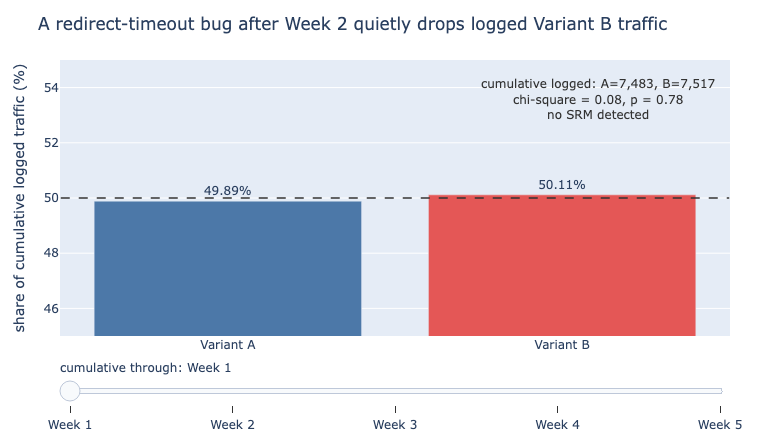

In [17]:
show(fig_srm_check())

## Multiple metrics, multiple chances to be wrong

The probability that at least one of k metrics clears a 95% win-probability bar, with no true difference behind any of them. The uncorrected rate climbs past 60% by twenty metrics; a per-metric threshold adjusted for k holds it near 5% throughout.

In [18]:
def fig_multiple_metrics() -> go.Figure:
    rng = np.random.default_rng(404)
    n_simulations = 30_000
    max_k = 20
    n_per_group = 2000
    true_rate = 0.10
    alpha = 0.05
    k_values = [1, 2, 3, 5, 8, 12, 16, 20]

    # Every metric shares the same true 10% rate for both variants (a true null on all of
    # them), and each metric's win probability comes from a Normal approximation to the two
    # Beta posteriors instead of a nested per-metric simulation loop: with n=2000 per arm the
    # Beta posterior sits close enough to Normal that the two-proportion z-score converts
    # directly to a win probability through the Normal CDF.
    a_conv = rng.binomial(n_per_group, true_rate, size=(n_simulations, max_k))
    b_conv = rng.binomial(n_per_group, true_rate, size=(n_simulations, max_k))
    p_a, p_b = a_conv / n_per_group, b_conv / n_per_group
    var_sum = p_a * (1 - p_a) / n_per_group + p_b * (1 - p_b) / n_per_group
    z = (p_b - p_a) / np.sqrt(var_sum + 1e-12)
    win_prob = stats.norm.cdf(z)

    frames = []
    for k in k_values:
        wp_k = win_prob[:, :k]
        frac_uncorrected = float(np.mean(np.any((wp_k > 0.975) | (wp_k < 0.025), axis=1)))

        z_crit = stats.norm.ppf(1 - (alpha / k) / 2)
        frac_corrected = float(np.mean(np.any(np.abs(z[:, :k]) > z_crit, axis=1)))

        frames.append(
            go.Frame(
                name=str(k),
                data=[go.Bar(x=["uncorrected, 95% win-prob rule", "Bonferroni-corrected"],
                              y=[frac_uncorrected, frac_corrected],
                              marker_color=["#E45756", "#4C78A8"],
                              text=[f"{frac_uncorrected:.1%}", f"{frac_corrected:.1%}"],
                              textposition="outside")],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=-0.5, x1=1.5, y0=0.05, y1=0.05,
                    line=dict(color="#333", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="At least one of k metrics clears a 95% win-probability bar by chance alone, "
              "with no true difference behind any of them",
        yaxis_title="probability at least one metric is flagged",
        yaxis_range=[0, 0.8],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "metrics tracked (k): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=80, l=60, r=30, b=50),
    )
    return fig

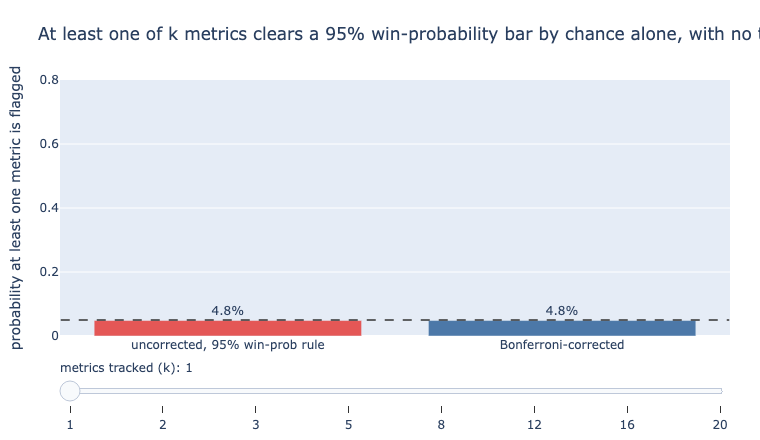

In [19]:
show(fig_multiple_metrics())

## Hierarchical A/B testing: partial pooling across segments

Left: the same elpd_loo comparison az.compare() produces, best model first. Right: each segment's true lift against what no pooling and partial pooling recovered from the data. Referral's near-zero no-pooling estimate, driven by a small sample landing close to even, moves toward the group pattern under partial pooling and lands close to its true 0.5-point lift; Email, the smallest segment, gets pulled the same direction even though its own true lift ran the other way.

Unlike every other figure in this chapter, this one has no closed-form shortcut: a hierarchical logistic model has no conjugate posterior, so the cell below runs PyMC's sampler directly on three models (no pooling, complete pooling, hierarchical partial pooling) and compares them with `az.compare()`.

In [20]:
def fig_hierarchical_segments() -> go.Figure:
    # Unlike the linear-Gaussian models in Chapters 9 and 10, a hierarchical logistic model has
    # no conjugate posterior, so this figure (the only one in the book) runs PyMC's sampler
    # directly instead of a closed-form approximation.
    import pymc as pm
    import arviz as az

    segments = ["organic", "paid_search", "referral", "email"]
    n_A = np.array([6000, 4000, 1200, 350])
    n_B = np.array([6000, 4000, 1200, 350])
    true_rate_A = np.array([0.095, 0.110, 0.080, 0.130])
    true_lift_pp = np.array([0.010, 0.030, 0.005, -0.010])
    true_rate_B = true_rate_A + true_lift_pp

    data_rng = np.random.default_rng(707)
    k_A = data_rng.binomial(n_A, true_rate_A)
    k_B = data_rng.binomial(n_B, true_rate_B)

    n_segments = len(segments)
    seg_idx = np.repeat(np.arange(n_segments), 2)
    arm_idx = np.tile(np.array([0, 1]), n_segments)
    n_all = np.empty(2 * n_segments, dtype=int)
    k_all = np.empty(2 * n_segments, dtype=int)
    n_all[0::2], n_all[1::2] = n_A, n_B
    k_all[0::2], k_all[1::2] = k_A, k_B

    def fit(pooling):
        coords = {"segment": segments, "obs_id": np.arange(2 * n_segments)}
        with pm.Model(coords=coords):
            alpha = pm.Normal("alpha", mu=0, sigma=1.5, dims="segment")
            if pooling == "no_pooling":
                delta = pm.Normal("delta", mu=0, sigma=1.5, dims="segment")
            elif pooling == "complete_pooling":
                delta_shared = pm.Normal("delta_shared", mu=0, sigma=1.5)
                delta = pm.Deterministic(
                    "delta", delta_shared * pm.math.ones(n_segments), dims="segment"
                )
            else:
                # Non-centered parameterization, the same funnel-avoiding trick Chapter 9 uses
                # for the horseshoe prior, applied here to the segment-level treatment effect.
                mu_delta = pm.Normal("mu_delta", mu=0, sigma=1)
                sigma_delta = pm.HalfNormal("sigma_delta", sigma=1)
                delta_offset = pm.Normal("delta_offset", mu=0, sigma=1, dims="segment")
                delta = pm.Deterministic(
                    "delta", mu_delta + delta_offset * sigma_delta, dims="segment"
                )
            p_all = pm.math.invlogit(alpha[seg_idx] + delta[seg_idx] * arm_idx)
            pm.Binomial("obs", n=n_all, p=p_all, observed=k_all, dims="obs_id")
            idata = pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.9,
                               random_seed=101, progressbar=False)
            pm.compute_log_likelihood(idata)
        return idata

    idata_no_pooling = fit("no_pooling")
    idata_complete_pooling = fit("complete_pooling")
    idata_hierarchical = fit("hierarchical")

    comparison = az.compare({
        "no_pooling": idata_no_pooling,
        "complete_pooling": idata_complete_pooling,
        "hierarchical": idata_hierarchical,
    })

    # arviz's compare() column names have moved between versions (elpd_loo/d_elpd/dSE in the
    # convention Chapter 10 uses, elpd/elpd_diff/dse in the version this book's dependencies
    # pin); read them from whichever set is present so this figure keeps working across an
    # arviz upgrade instead of raising a KeyError.
    elpd_col = "elpd_loo" if "elpd_loo" in comparison.columns else "elpd"
    se_col = "se" if "se" in comparison.columns else "SE"

    order = comparison.index.tolist()
    elpds = comparison.loc[order, elpd_col].astype(float).tolist()
    ses = comparison.loc[order, se_col].astype(float).tolist()

    def alpha_delta_means(idata):
        return (
            idata.posterior["alpha"].mean(dim=["chain", "draw"]).values,
            idata.posterior["delta"].mean(dim=["chain", "draw"]).values,
        )

    alpha_no, delta_no = alpha_delta_means(idata_no_pooling)
    alpha_hier, delta_hier = alpha_delta_means(idata_hierarchical)

    def invlogit(x):
        return 1.0 / (1.0 + np.exp(-x))

    lift_no = (invlogit(alpha_no + delta_no) - invlogit(alpha_no)) * 100
    lift_hier = (invlogit(alpha_hier + delta_hier) - invlogit(alpha_hier)) * 100
    lift_true = true_lift_pp * 100

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Model comparison", "Segment-level lift"),
        column_widths=[0.42, 0.58],
    )
    fig.add_trace(
        go.Scatter(
            x=elpds, y=order, mode="markers",
            error_x=dict(type="data", array=ses, color="#4C78A8", thickness=2, width=6),
            marker=dict(size=12, color="#4C78A8"), showlegend=False,
        ),
        row=1, col=1,
    )
    fig.update_yaxes(autorange="reversed", row=1, col=1)
    fig.update_xaxes(title_text="elpd_loo (higher is better)", row=1, col=1)

    fig.add_trace(
        go.Scatter(x=lift_true, y=segments, mode="markers", name="true lift",
                    marker=dict(symbol="diamond", size=13, color="#333")),
        row=1, col=2,
    )
    fig.add_trace(
        go.Scatter(x=lift_no, y=segments, mode="markers", name="no pooling",
                    marker=dict(symbol="circle", size=12, color="#E45756")),
        row=1, col=2,
    )
    fig.add_trace(
        go.Scatter(x=lift_hier, y=segments, mode="markers", name="hierarchical (partial pooling)",
                    marker=dict(symbol="square", size=11, color="#4C78A8")),
        row=1, col=2,
    )
    fig.add_vline(x=0, line=dict(color="#999", width=1, dash="dot"), row=1, col=2)
    fig.update_xaxes(title_text="posterior mean lift (percentage points)", row=1, col=2)
    # No overall figure title here: the surrounding chapter prose and this figure's own
    # caption carry that framing, and stacking a suptitle on top of both subplot titles and
    # the legend left too little vertical room for all three to stay legible.
    fig.update_layout(
        legend=dict(orientation="h", yanchor="bottom", y=1.16, xanchor="center", x=0.79),
        margin=dict(t=90, l=110, r=30, b=50),
    )
    return fig

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha, delta]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


/Users/Rudrendu/All Mac/project-code/VS_Code/content-system/books-all/open-source-books/Book 3 - Statistics for 
Data Scientists and Engineers/published-repo/.venv/lib/python3.14/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/Rudrendu/All Mac/project-code/VS_Code/content-system/books-all/open-source-books/Book 3 - Statistics for Data Scientists and Engineers/published-repo/.venv/lib/python3.14/site-packages/arviz_stats/loo/loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/Rudrendu/All Mac/project-code/VS_Code/content-system/books-all/open-source-books/Book 3 - Statistics for Data Scientists and Engineers/published-repo/.venv/lib/python3.14/site-packages/arviz_stats/loo/loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model

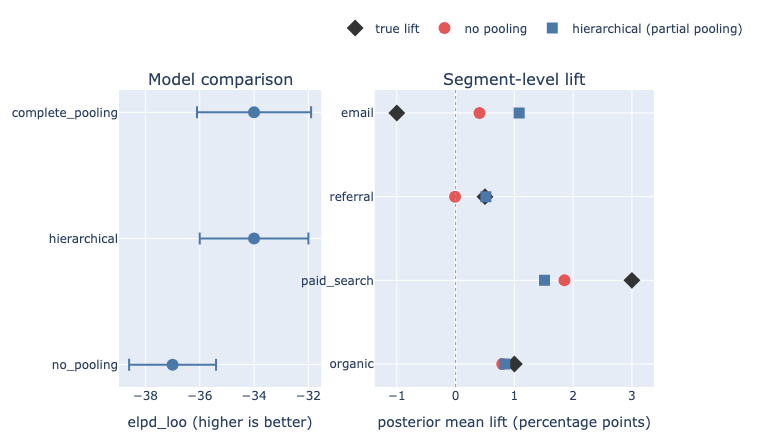

In [21]:
show(fig_hierarchical_segments(), height=440)

## Latent subgroups: what a mixture model finds when the segment isn't logged

Left: the pooled checkout-time change fit as one effect, a single Normal curve sitting between the data's two humps and matching neither well. Right: the same data fit as a two-component mixture. One cluster, 62% of simulated visitors, checks out about nine seconds faster; the other, 38%, checks out about six seconds slower.

In [22]:
def fig_latent_mixture() -> go.Figure:
    # Same reasoning as fig_hierarchical_segments: import PyMC locally so every other
    # figure in this script, and any environment that only needs those, never pays its
    # import cost.
    import pymc as pm

    rng = np.random.default_rng(505)
    n_users = 2400
    # Two latent groups the experiment platform never logs: visitors who have seen the
    # redesigned checkout before (it saves them time) and first-time visitors who are
    # still expecting the old flow (it costs them time). Only the pooled outcome is
    # observed; group membership is not.
    true_weight_returning = 0.62
    true_mean_returning, true_sd_returning = 9.0, 3.0
    true_mean_first_time, true_sd_first_time = -6.0, 4.5

    is_returning = rng.random(n_users) < true_weight_returning
    checkout_time_delta = np.where(
        is_returning,
        rng.normal(true_mean_returning, true_sd_returning, n_users),
        rng.normal(true_mean_first_time, true_sd_first_time, n_users),
    )

    naive_mean = float(checkout_time_delta.mean())
    naive_sd = float(checkout_time_delta.std())

    with pm.Model():
        weights = pm.Dirichlet("weights", a=np.ones(2))
        # The `ordered` transform pins component 0 below component 1 at every draw,
        # which is what keeps the sampler from flipping which component it calls "0"
        # partway through a chain (the label-switching problem the chapter text walks
        # through). Without it, two chains, or even two stretches of one chain, could
        # each be a valid fit while disagreeing on which cluster is which.
        means = pm.Normal(
            "means", mu=0, sigma=10, shape=2,
            transform=pm.distributions.transforms.ordered,
            initval=np.array([-6.0, 6.0]),
        )
        sigmas = pm.HalfNormal("sigmas", sigma=6, shape=2)
        pm.NormalMixture("checkout_time_change", w=weights, mu=means, sigma=sigmas,
                          observed=checkout_time_delta)
        idata = pm.sample(1500, tune=1500, chains=2, cores=1, target_accept=0.9,
                           random_seed=101, progressbar=False)

    w = idata.posterior["weights"].mean(dim=["chain", "draw"]).values
    mu = idata.posterior["means"].mean(dim=["chain", "draw"]).values
    sd = idata.posterior["sigmas"].mean(dim=["chain", "draw"]).values

    x = np.linspace(-25, 25, 400)
    x_list = x.tolist()
    counts, edges = np.histogram(checkout_time_delta, bins=40, density=True)
    centers = ((edges[:-1] + edges[1:]) / 2).tolist()
    widths = (edges[1:] - edges[:-1]).tolist()

    naive_fit = stats.norm.pdf(x, naive_mean, naive_sd).tolist()
    comp_harmed = (w[0] * stats.norm.pdf(x, mu[0], sd[0])).tolist()
    comp_helped = (w[1] * stats.norm.pdf(x, mu[1], sd[1])).tolist()
    mixture_fit = (np.array(comp_harmed) + np.array(comp_helped)).tolist()

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Aggregate view: one effect, one number",
                         "Two-component mixture: what the aggregate hides"),
    )
    fig.add_trace(go.Bar(x=centers, y=counts.tolist(), width=widths,
                          marker_color="#B7C7DB", opacity=0.7, showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=x_list, y=naive_fit, mode="lines",
                              line=dict(color="#333", width=2.5, dash="dash"),
                              name="single-Normal fit"), row=1, col=1)
    fig.add_vline(x=naive_mean, line=dict(color="#4C78A8", width=2), row=1, col=1)

    fig.add_trace(go.Bar(x=centers, y=counts.tolist(), width=widths,
                          marker_color="#B7C7DB", opacity=0.7, showlegend=False),
                  row=1, col=2)
    fig.add_trace(go.Scatter(x=x_list, y=comp_harmed, mode="lines", fill="tozeroy",
                              line=dict(color="#E45756", width=2),
                              name=f"harmed cluster (weight {w[0]:.0%})"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_list, y=comp_helped, mode="lines", fill="tozeroy",
                              line=dict(color="#4C78A8", width=2),
                              name=f"helped cluster (weight {w[1]:.0%})"), row=1, col=2)
    fig.add_trace(go.Scatter(x=x_list, y=mixture_fit, mode="lines",
                              line=dict(color="#333", width=2.5),
                              name="mixture fit"), row=1, col=2)

    fig.update_xaxes(title_text="change in checkout time (seconds, + saved / - added)")
    fig.update_yaxes(title_text="density", row=1, col=1)
    fig.update_layout(
        title="One aggregate effect hides two different visitor experiences",
        legend=dict(orientation="h", yanchor="bottom", y=1.16, xanchor="center", x=0.5),
        margin=dict(t=110, l=60, r=30, b=60),
    )
    return fig

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [weights, means, sigmas]


Sampling 2 chains for 1_500 tune and 1_500 draw iterations (3_000 + 3_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


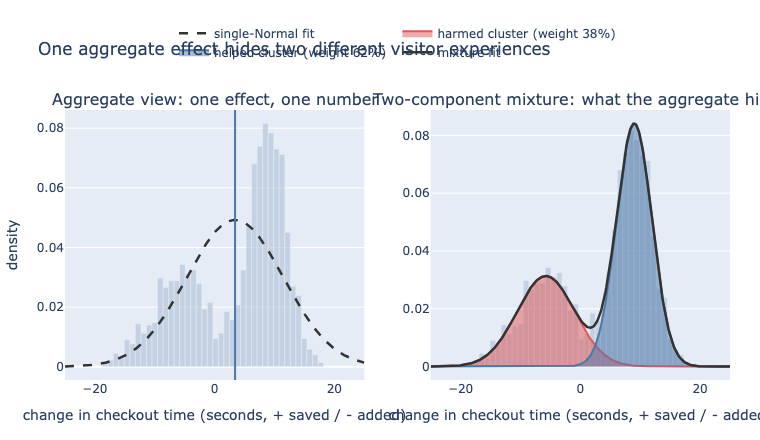

In [23]:
show(fig_latent_mixture())